# HOSPITAL READMISSION MODEL

# Step1. Business Understanding
Diabetes is one of the most serious and widespread chronic diseases in the world. According to the International Diabetes Federation, over 537 million adults were living with diabetes in 2021. In the United States alone, diabetes accounted for 32% of all hospital readmissions in 2018, making it one of the leading causes of rehospitalization alongside heart failure and septicemia.Many diabetic patients require continuous monitoring after discharge, and some experience complications that result in readmission shortly after leaving the hospital.

Frequent readmissions increase healthcare costs, place additional strain on hospital resources, and may indicate gaps in patient care, discharge planning, or follow-up treatment. By identifying patients who are at a higher risk of being readmitted, healthcare providers can intervene early through follow-up appointments, patient education, medication management, and other preventive measures.

## Problem Statement
Hospitals currently have no reliable, data-driven system to identify which diabetic patients are likely to be readmitted within 30 days. This means:
High-risk patients are discharged without additional support or monitoring
Hospitals face financial penalties for high readmission rates
Patients suffer unnecessary complications that could have been prevented

## Business Objective
Machine learning provides an opportunity to solve this. This project aims at building a machine learning model that will predict whether diabetic patients will be readmitted to the hospital within 30 days of discharge, using information available at the time of discharge such as: Patient demographic(Age, Race, Gender), Clinical details(Diagnosis, Lab Results, Time spent in hospital), Medication history, Admission and discharge details.

## Step 2. Data Preparation

## 2.1 Importing all the required libraries
Before we do the data preparation , we are going to import all the necessarry libraries required to complete this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")   # makes charts look cleaner by default
pd.set_option('display.max_columns', None)  # so pandas doesn't hide columns when printing

## 2.2 Loading the dataset
Here we are loading the dataset so we can start working with it.
After loading the dataset we will start exploring the data by checking the shape of the data, i.e the number of rows and columns, the information and the description, 

In [2]:
df = pd.read_csv('hospital_readmissions_30k.csv')
print(df.shape)

(30000, 12)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [4]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [5]:
df.describe(include='all').T

for c in ['gender', 'diabetes', 'hypertension', 'discharge_destination', 'readmitted_30_days']:
    print(c, df[c].unique())

gender ['Other' 'Female' 'Male']
diabetes ['Yes' 'No']
hypertension ['No' 'Yes']
discharge_destination ['Nursing_Facility' 'Home' 'Rehab']
readmitted_30_days ['Yes' 'No']


## 2.3 Data cleaning
We check the dataset for common problems like duplicated records, missing information, and values that don't make sense.


### 2.3.1 Checking duplicate records to prevent our numbers form looking bigger or skewed.


In [6]:
full_dupes = df.duplicated().sum()
id_dupes = df['patient_id'] .duplicated().sum()

print(f"fully duplicated rows: {full_dupes}")
print(f"duplicated patient IDs: {id_dupes}")

fully duplicated rows: 0
duplicated patient IDs: 0


In [7]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset='patient_id', keep='first')

### 2.3.2 Checking for Missing values

In [8]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

In [9]:
print("Missing values per column:")
print(df.isnull().sum())

placeholder_values = ['NA', 'N/A', 'na', 'n/a', 'Unknown', 'UNKNOWN', '?', '-', '', 'None', 'null']
print("\nRows with placeholder text per column:")
for c in df.select_dtypes(include='object').columns:
    hits = df[c].isin(placeholder_values).sum()
    if hits:
        print(f"  {c}: {hits}")

Missing values per column:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Rows with placeholder text per column:


In [10]:
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
for c in numeric_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

cat_cols = ['gender', 'diabetes', 'hypertension', 'discharge_destination', 'readmitted_30_days']
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

### 2.3.3 Checking for outliers and errors 

In [11]:
numeric_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

# quick range check
for c in numeric_cols:
    print(f"{c}: min={df[c].min()}, max={df[c].max()}")

age: min=18, max=90
cholesterol: min=150, max=300
bmi: min=18.0, max=40.0
medication_count: min=0, max=10
length_of_stay: min=1, max=10


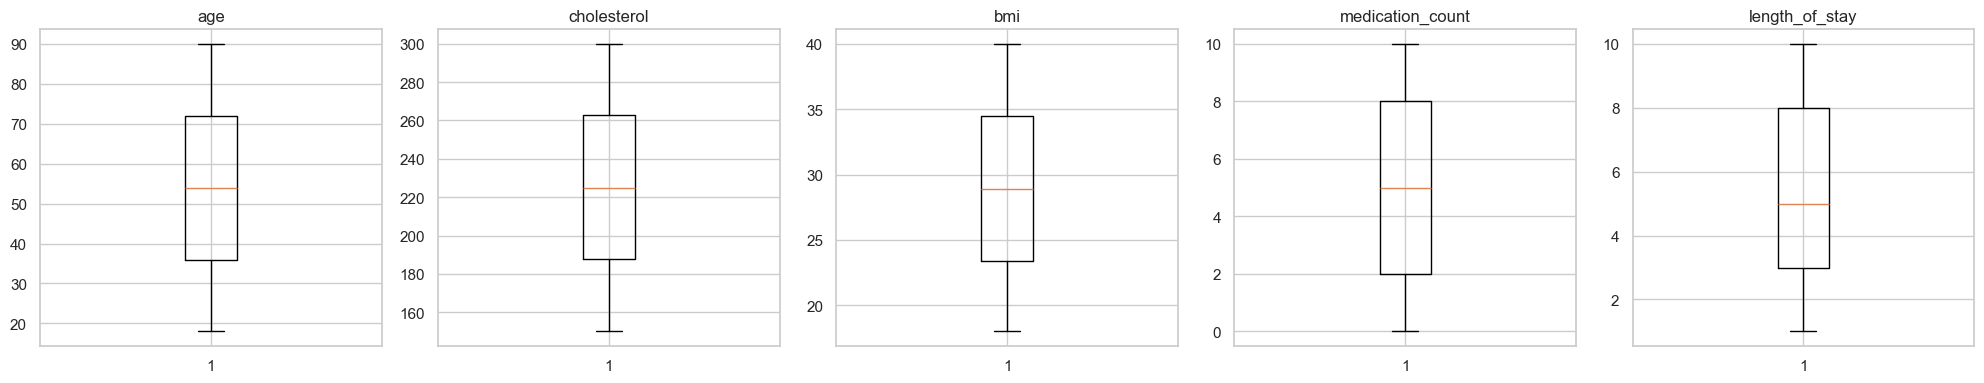

In [12]:
#visual check with boxplots - points far from the box are outliers
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax , c in zip(axes, numeric_cols):
    ax.boxplot(df[c])
    ax.set_title(c)
plt.tight_layout()
plt.show()    

In [13]:
#doing a statistical check using the interquartile rule 

def count_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for c in numeric_cols:
    print(f"{c}: {count_outliers(df[c])} outliers")

age: 0 outliers
cholesterol: 0 outliers
bmi: 0 outliers
medication_count: 0 outliers
length_of_stay: 0 outliers


In [14]:
# check blood pressure is always in the expected "systolic/diastolic" format,
# and that the numbers themselves are medically plausible
bp_split = df['blood_pressure'].str.extract(r'^(?P<systolic>\d+)/(?P<diastolic>\d+)$').astype(float)
bad_format = bp_split.isnull().any(axis=1).sum()
implausible = (
    (bp_split['systolic'] < 60) | (bp_split['systolic'] > 250) |
    (bp_split['diastolic'] < 30) | (bp_split['diastolic'] > 150)
).sum()

print(f"Blood pressure entries not in the expected format: {bad_format}")
print(f"Blood pressure entries outside a plausible range: {implausible}")

Blood pressure entries not in the expected format: 0
Blood pressure entries outside a plausible range: 0


### 2.3.4 Fixing the data formats
Since the blood pressure is stored as single piece of text file, combining the two separate numbers into one field, we are going to split it into systolic and diastolic as their own numerical columns before we proceed.
And since we also have columns with "Yes" or "No" as texts, that is ; diabetes, hypertension and whether the patient was readmitted, we are going to convert them into 0s and 1s to make it usable for statistics and for modelling.

In [15]:
#splitting the blood pressure into two separate numeric columns
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['blood_pressure'])

df[['systolic_bp', 'diastolic_bp']].head()

,systolic_bp,diastolic_bp
0,130,72
1,120,92
2,135,78
3,123,80
4,135,84


In [16]:
df.head(15)

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp
0,1,74,Other,240,31.5,Yes,No,5,1,Nursing_Facility,Yes,130,72
1,2,46,Female,292,36.3,No,No,4,3,Nursing_Facility,No,120,92
2,3,89,Other,153,30.3,No,Yes,1,1,Home,No,135,78
3,4,84,Female,153,31.5,No,Yes,3,10,Home,No,123,80
4,5,32,Other,205,18.4,No,Yes,6,4,Nursing_Facility,No,135,84
5,6,75,Female,194,33.5,No,Yes,0,10,Home,No,139,100
6,7,47,Male,168,27.1,No,Yes,5,8,Home,No,139,79
7,8,18,Other,210,26.3,No,No,5,2,Home,No,153,81
8,9,68,Male,218,30.4,No,Yes,3,8,Home,No,111,76
9,10,23,Female,186,21.3,No,No,3,3,Home,No,142,72


## Step 4 . Feature Engineering 
In this step we will be doing feature engineering, that is; creating new columns that will group the existing information into more meaningful buckets. We will feature engineer the raw data to improve the performance of our machine learning model. For example turning the age into age gap groups like 51 - 75, or flag patients who are on an unusually high number of medications.
The new columns often reveal patterns more clearly than using raw numbers alone , and they will make our charts easier to read later.


In [17]:
import numpy as np

# group age into bands
df['age_group'] = pd.cut(
    df['age'], bins=[17, 30, 45, 60, 75, 90],
    labels=['18-30', '31-45', '46-60', '61-75', '76-90']
)

df[['age', 'age_group']].head(10)


,age,age_group
0,74,61-75
1,46,46-60
2,89,76-90
3,84,76-90
4,32,31-45
5,75,61-75
6,47,46-60
7,18,18-30
8,68,61-75
9,23,18-30


In [18]:
# group BMI into standard weight categories
df['bmi_category'] = pd.cut(
    df['bmi'], bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df[['bmi', 'bmi_category']].head(10)

,bmi,bmi_category
0,31.5,Obese
1,36.3,Obese
2,30.3,Obese
3,31.5,Obese
4,18.4,Underweight
5,33.5,Obese
6,27.1,Overweight
7,26.3,Overweight
8,30.4,Obese
9,21.3,Normal


In [19]:
# classify blood pressure into standard categories
def bp_stage(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    elif s < 140 or d < 90:
        return 'Hypertension_Stage1'
    else:
        return 'Hypertension_Stage2'

df['bp_category'] = df.apply(bp_stage, axis=1).astype('category')

df[['systolic_bp', 'diastolic_bp', 'bp_category']].head(10)

,systolic_bp,diastolic_bp,bp_category
0,130,72,Hypertension_Stage1
1,120,92,Hypertension_Stage1
2,135,78,Hypertension_Stage1
3,123,80,Hypertension_Stage1
4,135,84,Hypertension_Stage1
5,139,100,Hypertension_Stage1
6,139,79,Hypertension_Stage1
7,153,81,Hypertension_Stage1
8,111,76,Normal
9,142,72,Hypertension_Stage1


In [20]:
# flag patients on a high number of medications, and count how many conditions they have
df['high_med_count'] = (df['medication_count'] >= 6).astype(int)
df['comorbidity_count'] = df['diabetes'] + df['hypertension']

df[['medication_count', 'high_med_count', 'diabetes', 'hypertension', 'comorbidity_count']].head(10)

,medication_count,high_med_count,diabetes,hypertension,comorbidity_count
0,5,0,Yes,No,YesNo
1,4,0,No,No,NoNo
2,1,0,No,Yes,NoYes
3,3,0,No,Yes,NoYes
4,6,1,No,Yes,NoYes
5,0,0,No,Yes,NoYes
6,5,0,No,Yes,NoYes
7,5,0,No,No,NoNo
8,3,0,No,Yes,NoYes
9,3,0,No,No,NoNo


## Step 5: Conducting normalization of the numbers

Since our numeric columns currently sits on different scales, i.e , cholestrol in hundreds while medication count in single digits . We are going to create standardized versions of these columns , where every number is rescaled so they are all measured on the same footing , so as to prevent our models from viewing larger numbers as of more weight than they actually posess just because they are large.

We are going to keep the original columns too, so our charts and summaries still show real and meaningful numbers like the actual age or actual cholestrol.

In [21]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay',
              'systolic_bp', 'diastolic_bp']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])

scaled_df = pd.DataFrame(scaled_values, columns=[f"{c}_scaled" for c in scale_cols], index=df.index)
df = pd.concat([df, scaled_df], axis=1)

df[[f"{c}_scaled" for c in scale_cols]].head(10)

,age_scaled,cholesterol_scaled,bmi_scaled,medication_count_scaled,length_of_stay_scaled,systolic_bp_scaled,diastolic_bp_scaled
0,0.955340,0.338181,0.402284,-0.003874,-1.570459,-0.338645,-1.459778
1,-0.374439,1.531254,1.158416,-0.319697,-0.872927,-1.020252,0.781643
2,1.667721,-1.657921,0.213251,-1.267166,-1.570459,0.002158,-0.787351
3,1.430261,-1.657921,0.402284,-0.635520,1.568436,-0.815770,-0.563209
4,-1.039328,-0.464849,-1.661326,0.311949,-0.524161,0.002158,-0.114925
5,1.002832,-0.717229,0.717339,-1.582989,1.568436,0.274801,1.678212
6,-0.326947,-1.313766,-0.290837,-0.003874,0.870904,0.274801,-0.675280
7,-1.704218,-0.350130,-0.416859,-0.003874,-1.221693,1.229050,-0.451138
8,0.670387,-0.166580,0.229003,-0.635520,0.870904,-1.633697,-1.011493
9,-1.466757,-0.900779,-1.204497,-0.635520,-0.872927,0.479283,-1.459778


In [22]:
#Double checking
df[[f"{c}_scaled" for c in scale_cols]].describe().T[['mean', 'std']]

,mean,std
age_scaled,-5.234331e-17,1.000017
cholesterol_scaled,-1.033840e-16,1.000017
bmi_scaled,4.031146e-16,1.000017
medication_count_scaled,-1.203186e-16,1.000017
length_of_stay_scaled,-1.058709e-16,1.000017
systolic_bp_scaled,-3.079019e-17,1.000017
diastolic_bp_scaled,-7.932025e-16,1.000017


## Step 6. Checking the distibution
We are going to check the distribution by plotting the numeric columns to show us the overall shape of the data , and whether the values are spread out wvwnly, clustered around a middle point , or leaning heavily to one side . 
This is to give us a sense of what's typical in our patient population and can flag anything unusual we might have missed in our earlier checks.

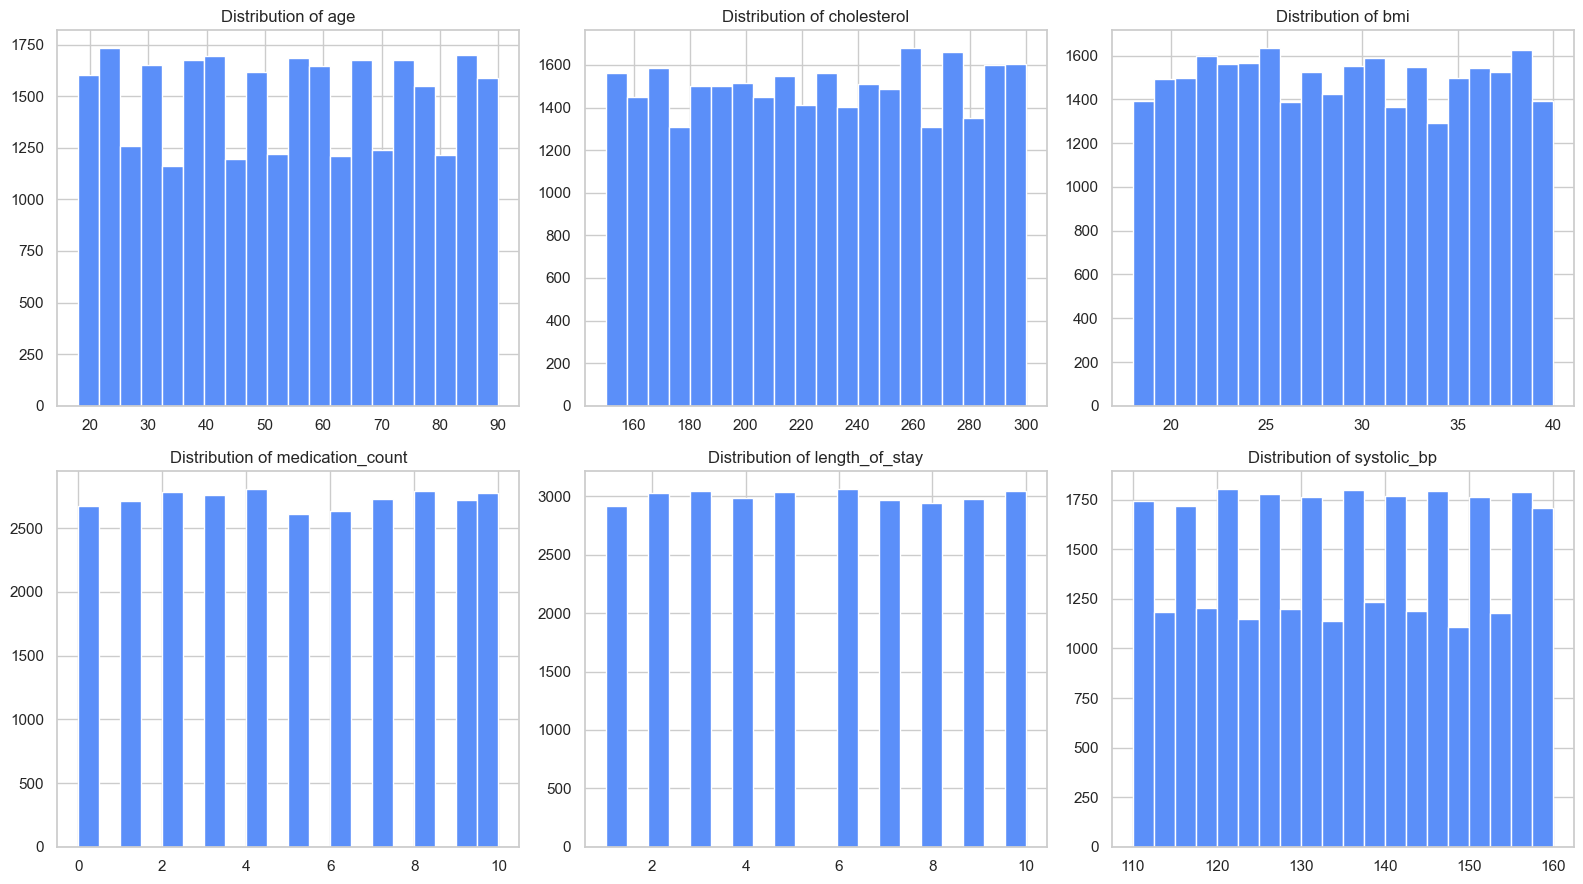

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

dist_cols = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic_bp']

for ax, c in zip(axes, dist_cols):
    ax.hist(df[c], bins=20, color='#5B8FF9', edgecolor='white')
    ax.set_title(f"Distribution of {c}")

plt.tight_layout()
plt.show()

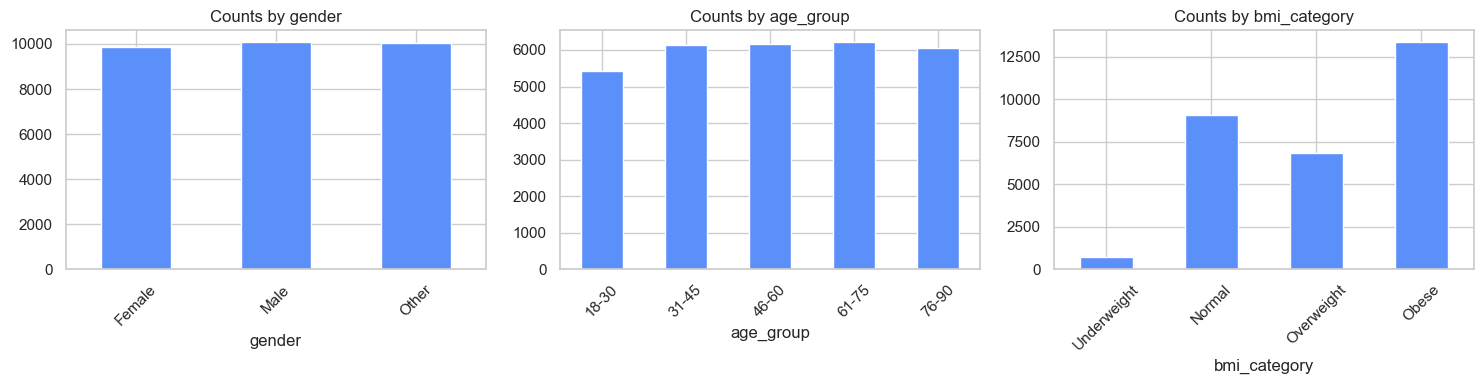

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, c in zip(axes, ['gender', 'age_group', 'bmi_category']):
    df[c].value_counts().sort_index().plot(kind='bar', ax=ax, color='#5B8FF9')
    ax.set_title(f"Counts by {c}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## step 7. Cheching calss balance
Since readmitted within 30days is the outcome we want to predict and understand, its important to check how balanced it is before we continue.

If it says, 90% of patients were not readmitted and only 10% were, that imbalance matters.

In [25]:
counts = df['readmitted_30_days'].value_counts()
percentages = df['readmitted_30_days'].value_counts(normalize=True) * 100

print(counts)
print(percentages.round(2))

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64
readmitted_30_days
No     87.75
Yes    12.25
Name: proportion, dtype: float64


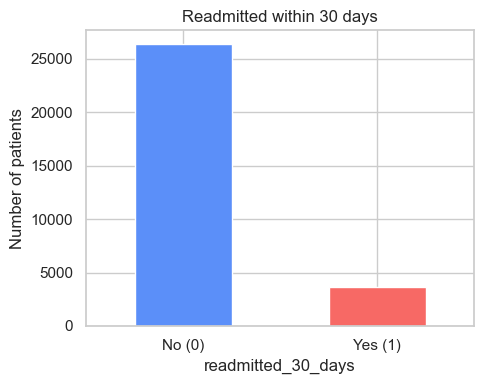

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', color=['#5B8FF9', '#F76965'], ax=ax)
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
ax.set_title('Readmitted within 30 days')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

In [27]:
#Saving the cleaned dataset

df.to_csv('hospital_readmissions_30k_cleaned.csv', index=False)
print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Saved cleaned dataset: 30000 rows, 25 columns
